In [1]:
import pandas as pd

# Nama file Excel yang sesuai
file_excel = "Monev Kegiatan HHI.xlsx"

# Membaca ketiga sheet
df_krt = pd.read_excel(file_excel, sheet_name="Monev KRT")
df_strategis = pd.read_excel(file_excel, sheet_name="Monev Strategis")
df_kerjasama = pd.read_excel(file_excel, sheet_name="Monev Kerjasama")

# Cek hasil baca data untuk Monev KRT
print("--- Data Monev KRT ---")
display(df_krt.head(3))

c:\Users\fadjr\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


--- Data Monev KRT ---


c:\Users\fadjr\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\fadjr\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NO,PEKERJAAN,PIC,UNIT,START,END,% PROGRES,BAR PROGRES,STATUS,KETERANGAN
1,NaN,Permohonan Security,Ganjar,Daop 2,2026-02-24 00:00:00,2026-03-11 00:00:00,1,NaN,SELESAI,NaN
2,NaN,Surat permohonan penambahan anggaran untuk keg...,Ganjar,FMB,NaN,NaN,1,NaN,SELESAI,Anggaran kegiatan strategis dialokasikan ke te...


In [2]:
# Memperbaiki header agar baris ke-1 di Excel dijadikan nama kolom resmi
df_krt = pd.read_excel(file_excel, sheet_name="Monev KRT", header=1)
df_strategis = pd.read_excel(
    file_excel, sheet_name="Monev Strategis", header=1
)
df_kerjasama = pd.read_excel(
    file_excel, sheet_name="Monev Kerjasama", header=1
)

# Cek kembali hasil pembersihan data Monev KRT
display(df_krt.head(3))

c:\Users\fadjr\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\fadjr\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\fadjr\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,NO,PEKERJAAN,PIC,UNIT,START,END,% PROGRES,BAR PROGRES,STATUS,KETERANGAN
0,NaN,Permohonan Security,Ganjar,Daop 2,2026-02-24,2026-03-11,1.0,NaN,SELESAI,NaN
1,NaN,Surat permohonan penambahan anggaran untuk keg...,Ganjar,FMB,NaT,NaT,1.0,NaN,SELESAI,Anggaran kegiatan strategis dialokasikan ke te...
2,NaN,RDS Permohonan Mobilisasi Cipunegara,Meta,FFG,NaT,NaT,1.0,NaN,SELESAI,NaN


In [3]:
# Mengubah format kolom % PROGRESS menjadi tampilan persen
for df in [df_krt, df_strategis, df_kerjasama]:
  if "% PROGRES" in df.columns:
    # Ubah ke angka persentase lalu jadikan string dengan tanda '%'
    df["% PROGRES"] = (df["% PROGRES"] * 100).fillna(0).astype(int).astype(str) + "%"

# Cek hasil setelah diubah
display(df_krt.head(3))

,NO,PEKERJAAN,PIC,UNIT,START,END,% PROGRES,BAR PROGRES,STATUS,KETERANGAN
0,NaN,Permohonan Security,Ganjar,Daop 2,2026-02-24,2026-03-11,100%,NaN,SELESAI,NaN
1,NaN,Surat permohonan penambahan anggaran untuk keg...,Ganjar,FMB,NaT,NaT,100%,NaN,SELESAI,Anggaran kegiatan strategis dialokasikan ke te...
2,NaN,RDS Permohonan Mobilisasi Cipunegara,Meta,FFG,NaT,NaT,100%,NaN,SELESAI,NaN


C:\Users\fadjr\AppData\Local\Temp\ipykernel_15796\2926961113.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_krt, df_strategis, df_kerjasama], ignore_index=True)


--- Ringkasan Status Keseluruhan ---
STATUS
ON PROGRES    39
SELESAI       29
PENDING        2
Name: count, dtype: int64


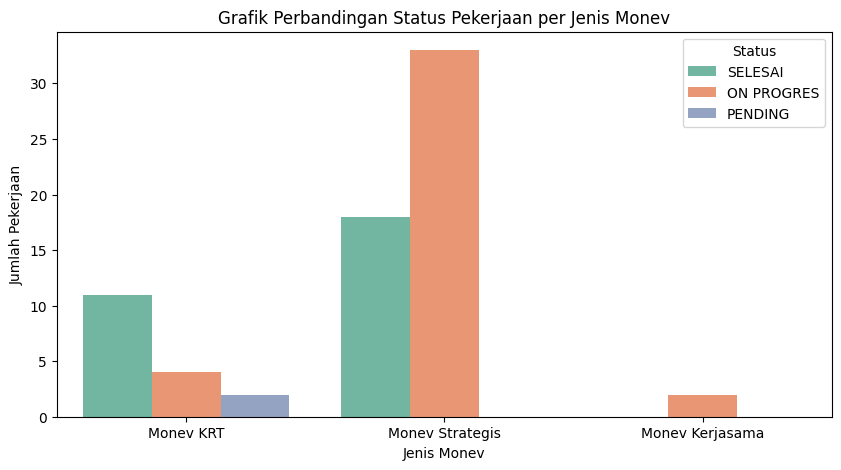

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menambahkan kolom kategori jenis monev di masing-masing dataframe
df_krt['KATEGORI_MONEV'] = 'Monev KRT'
df_strategis['KATEGORI_MONEV'] = 'Monev Strategis'
df_kerjasama['KATEGORI_MONEV'] = 'Monev Kerjasama'

# Menggabungkan ketiga dataframe jadi satu untuk analisis keseluruhan
df_all = pd.concat([df_krt, df_strategis, df_kerjasama], ignore_index=True)

# Menghitung jumlah status pekerjaan secara keseluruhan
print("--- Ringkasan Status Keseluruhan ---")
print(df_all['STATUS'].value_counts())

# Membuat grafik batang sederhana untuk melihat status per jenis monev
plt.figure(figsize=(10, 5))
sns.countplot(data=df_all, x='KATEGORI_MONEV', hue='STATUS', palette='Set2')
plt.title('Grafik Perbandingan Status Pekerjaan per Jenis Monev')
plt.xlabel('Jenis Monev')
plt.ylabel('Jumlah Pekerjaan')
plt.legend(title='Status')
plt.show()

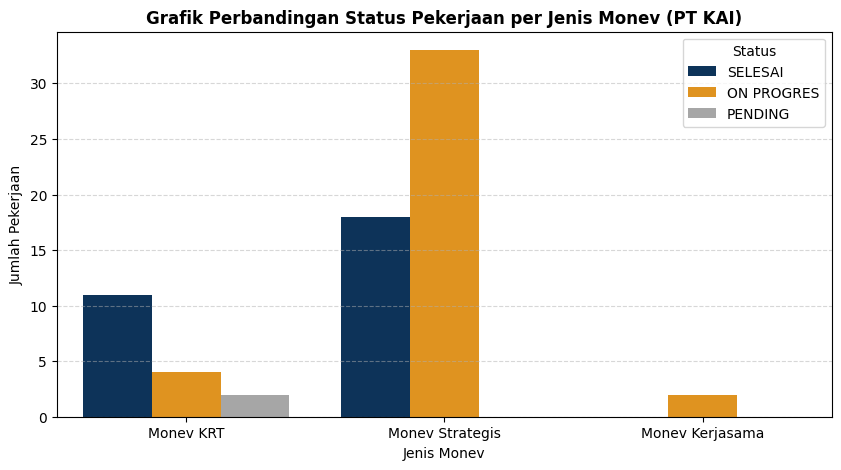

In [5]:
# Menyesuaikan palet warna ala PT KAI (Biru KAI dan Oranye/Kuning Emas)
# Urutan warna untuk: SELESAI, ON PROGRESS, PENDING
warna_kai = ['#003366', '#FF9900', '#A6A6A6']

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_all,
    x='KATEGORI_MONEV',
    hue='STATUS',
    palette=sns.color_palette(warna_kai),
)

plt.title(
    'Grafik Perbandingan Status Pekerjaan per Jenis Monev (PT KAI)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Jenis Monev', fontsize=10)
plt.ylabel('Jumlah Pekerjaan', fontsize=10)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

--- Tabel Rekapitulasi Berdasarkan Unit ---


,UNIT,JUMLAH_PEKERJAAN
4,FFG,5
18,KKO,5
5,FM,4
10,FS,3
6,FMA,2
7,FMB,2
17,KAI Wisata,2
15,ITO,2
0,All Direktorat,1
14,IT,1


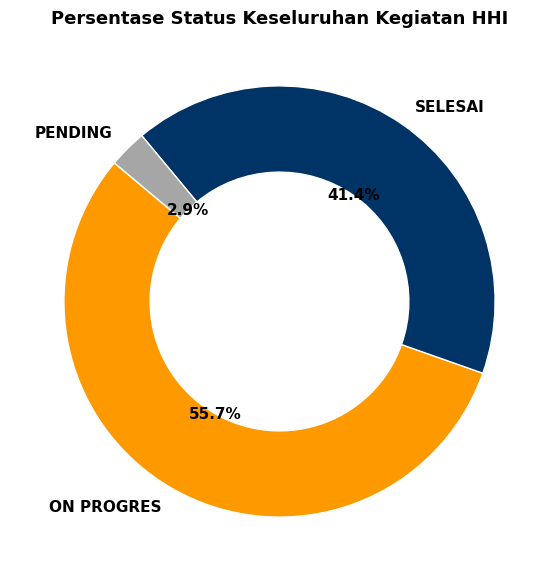

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tabel Ringkasan Pekerjaan per Unit
print("--- Tabel Rekapitulasi Berdasarkan Unit ---")
df_unit = df_all.groupby('UNIT')['PEKERJAAN'].count().reset_index()
df_unit.columns = ['UNIT', 'JUMLAH_PEKERJAAN']
df_unit = df_unit.sort_values(by='JUMLAH_PEKERJAAN', ascending=False)
display(df_unit)

# 2. Membuat Pie Chart / Donut Chart Persentase Status Keseluruhan
status_counts = df_all['STATUS'].value_counts()

plt.figure(figsize=(7, 7))
warna_status = ['#FF9900', '#003366', '#A6A6A6']  # Oranye, Biru, Abu

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=warna_status[: len(status_counts)],
    wedgeprops=dict(width=0.4, edgecolor='w'),  # Membuat efek Donut Chart
    textprops={'fontsize': 11, 'fontweight': 'bold'},
)

plt.title(
    'Persentase Status Keseluruhan Kegiatan HHI',
    fontsize=13,
    fontweight='bold',
)
plt.show()

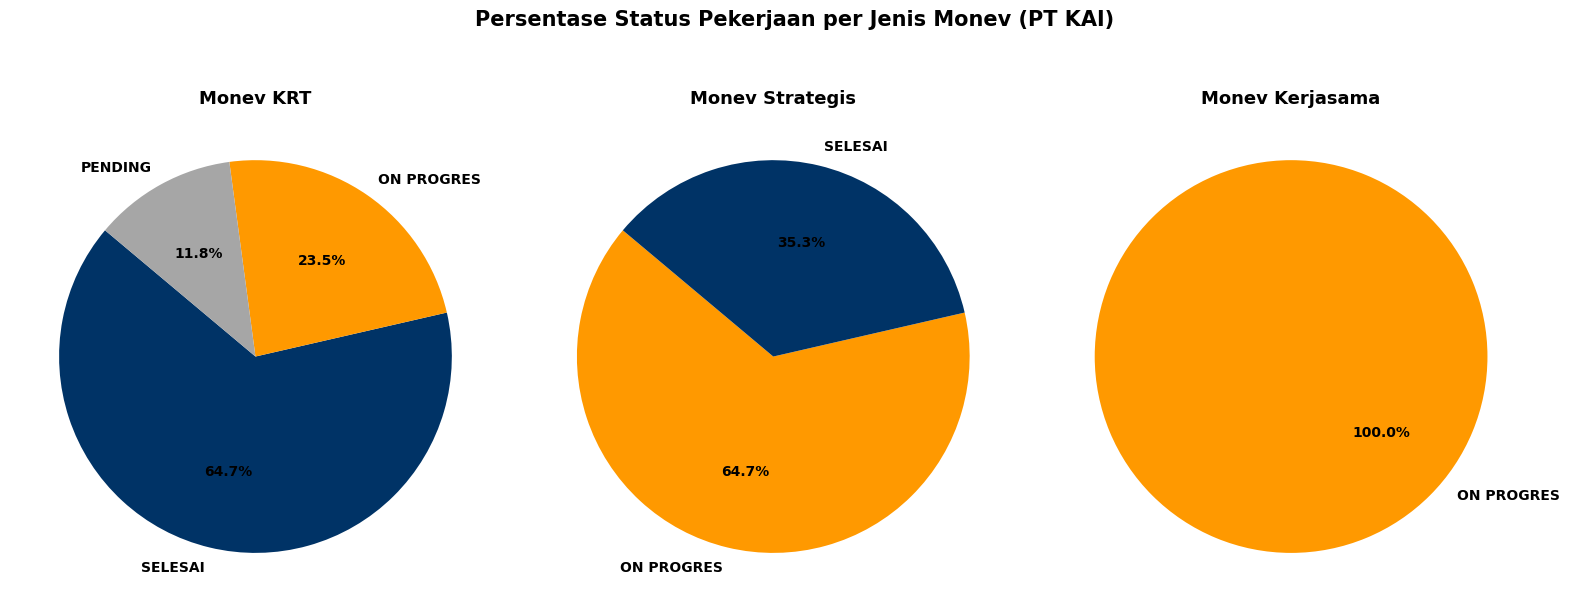

In [9]:
import matplotlib.pyplot as plt

# Menyiapkan 3 kolom pie chart penuh berdampingan
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

dfs = [
    ("Monev KRT", df_krt),
    ("Monev Strategis", df_strategis),
    ("Monev Kerjasama", df_kerjasama),
]

# Warna konsisten ala PT KAI: Selesai (Biru Tua), On Progres (Oranye), Pending (Abu)
warna_status_dict = {
    "SELESAI": "#003366",
    "ON PROGRES": "#FF9900",
    "PENDING": "#A6A6A6",
}

for i, (nama_monev, df_target) in enumerate(dfs):
  if "STATUS" in df_target.columns:
    status_counts_sub = df_target["STATUS"].value_counts()

    pie_colors = [
        warna_status_dict.get(st, "#333333") for st in status_counts_sub.index
    ]

    # Membuat Pie Chart penuh (parameter width dihapus)
    axes[i].pie(
        status_counts_sub.values,
        labels=status_counts_sub.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=pie_colors,
        textprops={"fontsize": 10, "fontweight": "bold"},
    )
    axes[i].set_title(nama_monev, fontsize=13, fontweight="bold")

plt.suptitle(
    "Persentase Status Pekerjaan per Jenis Monev (PT KAI)",
    fontsize=15,
    fontweight="bold",
    y=1.05,
)
plt.tight_layout()
plt.show()

 RINGKASAN EKSKLUTIF DASHBOARD Kegiatan HHI
 Total Kegiatan   : 71
 Selesai          : 29 (40.8%)
 On Progress      : 39 (54.9%)
 Pending          : 2


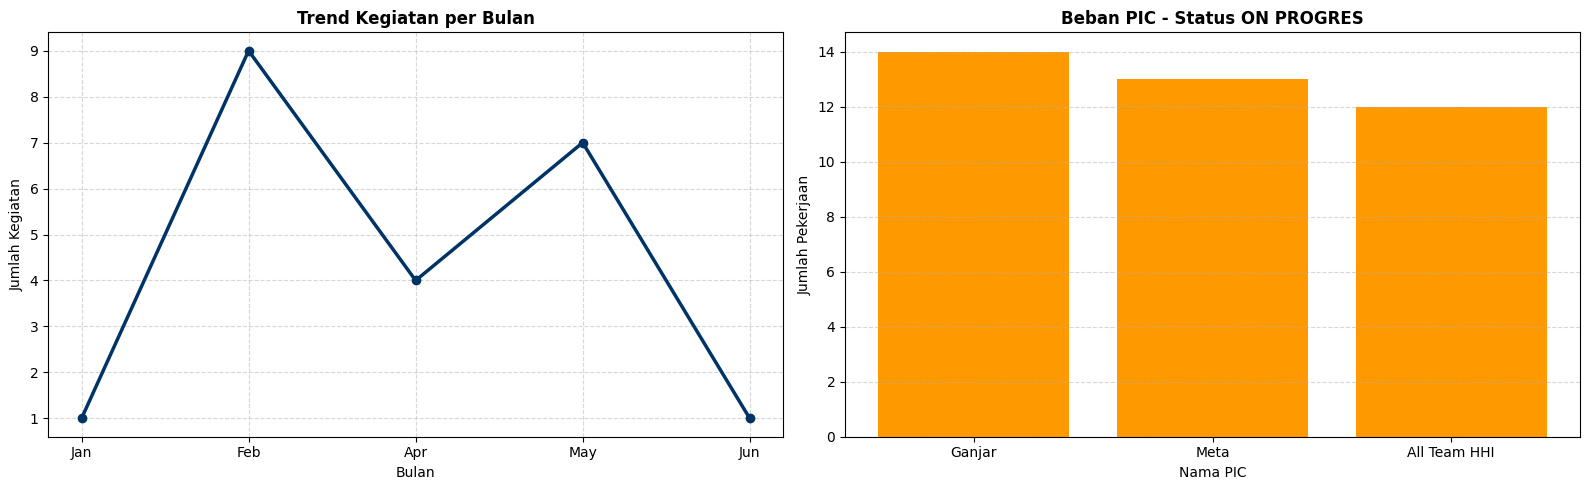

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Pastikan data sudah digabung dan kolom tanggal terbaca sebagai datetime
df_all["START_DT"] = pd.to_datetime(df_all["START"], errors="coerce")
df_all["BULAN"] = df_all["START_DT"].dt.strftime("%b")  # Format Nama Bulan (Jan, Feb, dst)

# 1. Menghitung Ringkasan KPI Cards Keseluruhan
total_kegiatan = len(df_all)
jumlah_selesai = len(df_all[df_all["STATUS"] == "SELESAI"])
jumlah_on_progres = len(df_all[df_all["STATUS"] == "ON PROGRES"])
jumlah_pending = (
    len(df_all[df_all["STATUS"] == "PENDING"])
    if "PENDING" in df_all["STATUS"].values
    else 0
)
persen_total = "100.0%"

print("=========================================")
print(f" RINGKASAN EKSKLUTIF DASHBOARD Kegiatan HHI")
print("=========================================")
print(f" Total Kegiatan   : {total_kegiatan}")
print(
    f" Selesai          : {jumlah_selesai} ({round(jumlah_selesai/total_kegiatan*100, 1)}%)"
)
print(
    f" On Progress      : {jumlah_on_progres} ({round(jumlah_on_progres/total_kegiatan*100, 1)}%)"
)
print(f" Pending          : {jumlah_pending}")
print("=========================================")

# 2. Membuat Visualisasi Pendukung (Trend Bulanan & PIC On Progress)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# A. Trend Kegiatan per Bulan (Line Chart)
trend_bulan = (
    df_all.dropna(subset=["BULAN"])
    .groupby("BULAN")["PEKERJAAN"]
    .count()
    .reindex(
        [
            "Jan",
            "Feb",
            "Mar",
            "Apr",
            "May",
            "Jun",
            "Jul",
            "Aug",
            "Sep",
            "Oct",
            "Nov",
            "Dec",
        ]
    )
    .dropna()
)

if not trend_bulan.empty:
  axes[0].plot(
      trend_bulan.index,
      trend_bulan.values,
      marker="o",
      color="#003366",
      linewidth=2.5,
      markersize=6,
  )
  axes[0].set_title(
      "Trend Kegiatan per Bulan", fontsize=12, fontweight="bold"
  )
  axes[0].set_xlabel("Bulan", fontsize=10)
  axes[0].set_ylabel("Jumlah Kegiatan", fontsize=10)
  axes[0].grid(True, linestyle="--", alpha=0.5)
else:
  axes[0].text(
      0.5,
      0.5,
      "Data Bulan Belum Cukup",
      ha="center",
      va="center",
      fontsize=12,
  )
  axes[0].set_title("Trend Kegiatan per Bulan", fontsize=12, fontweight="bold")

# B. Beban Kerja PIC untuk Status 'ON PROGRES' (Bar Chart)
df_on_progres = df_all[df_all["STATUS"] == "ON PROGRES"]
if "PIC" in df_on_progres.columns and not df_on_progres.empty:
  pic_op = df_on_progres["PIC"].value_counts()
  axes[1].bar(pic_op.index, pic_op.values, color="#FF9900")
  axes[1].set_title(
      "Beban PIC - Status ON PROGRES", fontsize=12, fontweight="bold"
  )
  axes[1].set_xlabel("Nama PIC", fontsize=10)
  axes[1].set_ylabel("Jumlah Pekerjaan", fontsize=10)
  axes[1].grid(axis="y", linestyle="--", alpha=0.5)
else:
  axes[1].text(
      0.5,
      0.5,
      "Tidak ada data On Progres / PIC",
      ha="center",
      va="center",
      fontsize=12,
  )
  axes[1].set_title(
      "Beban PIC - Status ON PROGRES", fontsize=12, fontweight="bold"
  )

plt.tight_layout()
plt.show()